Shreeeja Shrestha

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [144]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of FruitinAmazon.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [145]:
import os
os.listdir("/content/data")

['FruitinAmazon']

Task 1: Data Understanding and Visualization: Download the Provided Data and Complete the following task.
. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.
• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.

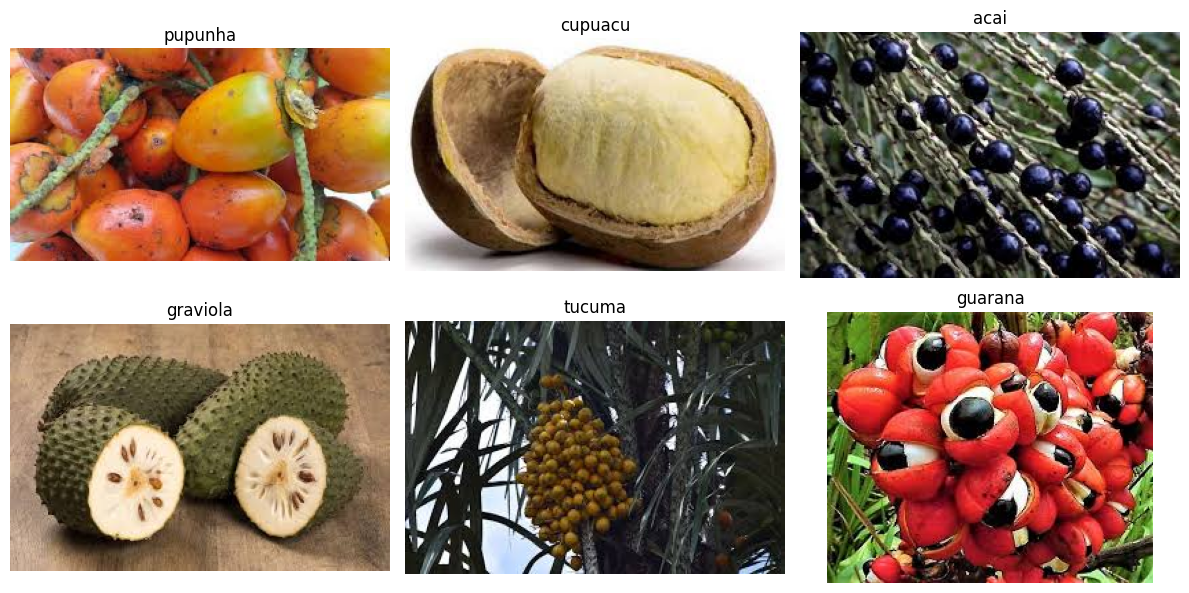

In [169]:

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/data/FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)

images = []

# Pick one random image from each class
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    img = Image.open(img_path)
    images.append((img, cls))

# Plot images in grid (2 rows)
plt.figure(figsize=(12, 6))

for i, (img, label) in enumerate(images):
    plt.subplot(2, (len(images)+1)//2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

Check wheather the image is corrupted or not

In [170]:
from PIL import Image
import os

train_dir = "/content/data/FruitinAmazon/train"
corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # verify image integrity
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


Task2: LoadingandPreprocessingImageDatainkeras:

In [171]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/data/FruitinAmazon/train"

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: Implementation of Convolutional Neural Network (CNN)

In [172]:
from tensorflow.keras import layers, models

num_classes = len(os.listdir(train_dir))

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Compile model


In [173]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train Model

In [174]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.1701 - loss: 2.0895

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 986ms/step - accuracy: 0.1667 - loss: 2.2647 - val_accuracy: 0.0556 - val_loss: 1.5773
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.2095 - loss: 1.8121

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step - accuracy: 0.2222 - loss: 1.7907 - val_accuracy: 0.7778 - val_loss: 1.2525
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.4028 - loss: 1.5812 - val_accuracy: 0.4444 - val_loss: 1.6015
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - accuracy: 0.3611 - loss: 1.4660 - val_accuracy: 0.7778 - val_loss: 1.0961
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.5000 - loss: 1.2071 - val_accuracy: 0.7778 - val_loss: 0.8075
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.4861 - loss: 1.0695 - val_accuracy: 0.6667 - val_loss: 1.0843
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.6944 - loss: 0.9174 - val_accuracy: 0.7222 - val_loss: 0.9357
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.7650 - loss: 0.7116

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 784ms/step - accuracy: 0.7639 - loss: 0.6952 - val_accuracy: 0.8333 - val_loss: 0.6222
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - accuracy: 0.9167 - loss: 0.4763 - val_accuracy: 0.8333 - val_loss: 0.6893
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - accuracy: 0.9722 - loss: 0.3049 - val_accuracy: 0.5556 - val_loss: 1.0467
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.9444 - loss: 0.2409 - val_accuracy: 0.8333 - val_loss: 0.6024
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - accuracy: 0.9861 - loss: 0.1281 - val_accuracy: 0.8333 - val_loss: 0.6788
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 1.0000 - loss: 0.1054 - val_accuracy: 0.7778 - val_loss: 0.8657
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 1.0000 - loss: 0.0622 - val_accuracy: 0.7778 - val_loss: 0.4180
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 0.0520 - val_accuracy: 0.8333 - val_loss: 

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.8889 - val_loss: 0.3137
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8889 - val_loss: 0.2667
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8889 - val_loss: 0.2658
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 519ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8889 - val_loss: 0.2819
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8889 - val_loss: 0.3161
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 749ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8889 - val_loss: 0.3525
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - accuracy: 1.0000 - loss: 9.6960e-04 - val_accuracy: 0.8889 - val_loss: 0.3854
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - accuracy: 1.0000 - loss: 8.7068e-04 - val_accuracy: 0.8889 

Visualization

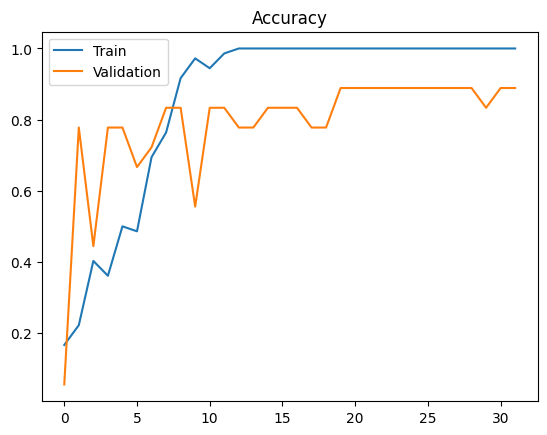

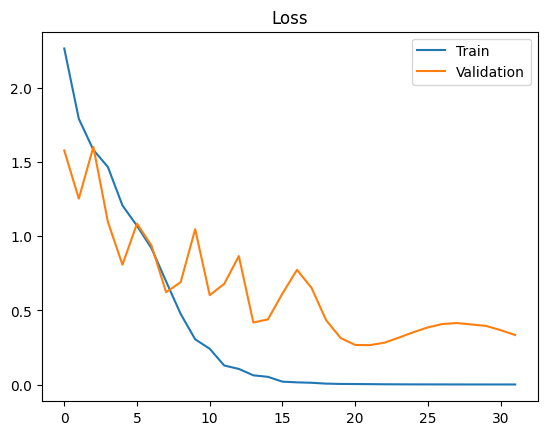

In [175]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Evaluate

In [160]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=16,
    shuffle=False
)

#  SAVE class names HERE (important!)
class_names = test_ds.class_names

Found 90 files belonging to 6 classes.


Task 5: Evaluate the Model

Evaluate

In [176]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8889 - loss: 0.2658
Test Accuracy: 0.8888888955116272
Test Loss: 0.26576945185661316


Save Model

Load Model

In [177]:
# Save
model.save("fruit_classifier.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_classifier.h5")

# Re-evaluate
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step - accuracy: 0.8889 - loss: 0.2658


[0.26576945185661316, 0.8888888955116272]

Task 7: Predictions + Classification Report

Step 1: Get Predictions

In [181]:
import numpy as np

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


Step 2: Get True Labels

In [182]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Step 3: Classification Report

In [183]:
from sklearn.metrics import classification_report

class_names = test_ds.class_names

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      1.00      1.00        15
     cupuacu       0.82      0.93      0.88        15
    graviola       0.93      0.87      0.90        15
     guarana       0.92      0.80      0.86        15
     pupunha       0.85      0.73      0.79        15
      tucuma       0.78      0.93      0.85        15

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



Plot

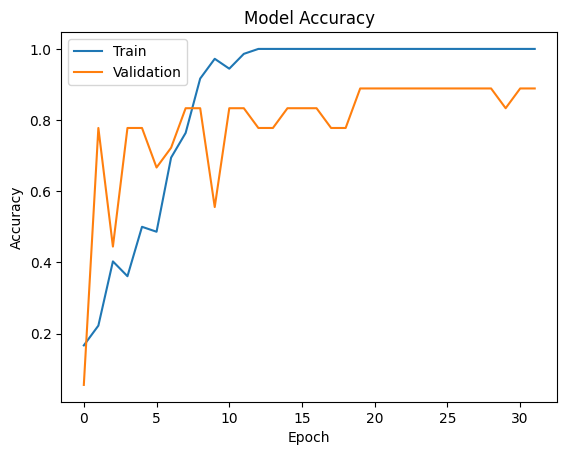

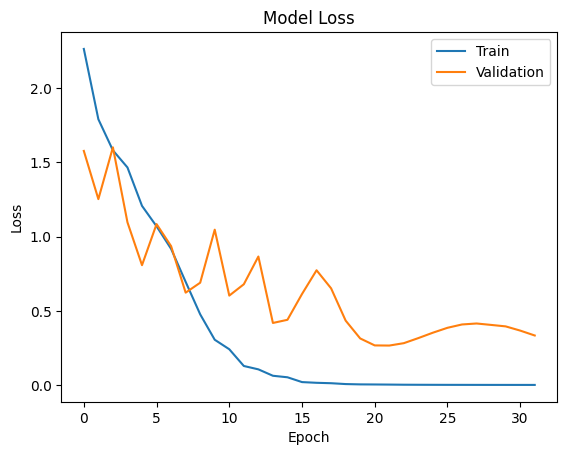

In [184]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()